In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
base_path = "/Users/admin/Documents/MITMaterial/TY_Material/Sem_6/ML/ML_Lab/fifa-world-cup"

In [3]:
worldcups = pd.read_csv(f"{base_path}/WorldCups.csv")
matches = pd.read_csv(f"{base_path}/WorldCupMatches.csv")
players = pd.read_csv(f"{base_path}/WorldCupPlayers.csv")

In [4]:
worldcups.head()

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590.549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363.000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375.700
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22,1.045.246
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26,768.607


In [5]:
matches.head()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,2549.0,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,23409.0,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA


In [6]:
players.head()

,RoundID,MatchID,Team Initials,Coach Name,Line-up,Shirt Number,Player Name,Position,Event
0,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Alex THEPOT,GK,NaN
1,201,1096,MEX,LUQUE Juan (MEX),S,0,Oscar BONFIGLIO,GK,NaN
2,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Marcel LANGILLER,NaN,G40'
3,201,1096,MEX,LUQUE Juan (MEX),S,0,Juan CARRENO,NaN,G70'
4,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Ernest LIBERATI,NaN,NaN


In [7]:
type(matches)

pandas.core.frame.DataFrame

In [8]:
matches.select_dtypes(include="number").columns

Index(['Year', 'Home Team Goals', 'Away Team Goals', 'Attendance',
       'Half-time Home Goals', 'Half-time Away Goals', 'RoundID', 'MatchID'],
      dtype='object')

In [9]:
valid_numeric_cols = [
    "Year",
    "Attendance",
    "Home Team Goals",
    "Away Team Goals",
    "Half-time Home Goals",
    "Half-time Away Goals"
]
matches[valid_numeric_cols].skew()

Year                   -0.664108
Attendance              0.818902
Home Team Goals         1.351740
Away Team Goals         1.510452
Half-time Home Goals    1.570043
Half-time Away Goals    2.173134
dtype: float64

In [10]:
worldcups.isna().sum()

Year              0
Country           0
Winner            0
Runners-Up        0
Third             0
Fourth            0
GoalsScored       0
QualifiedTeams    0
MatchesPlayed     0
Attendance        0
dtype: int64

In [11]:
matches.isna().sum()

Year                    3720
Datetime                3720
Stage                   3720
Stadium                 3720
City                    3720
Home Team Name          3720
Home Team Goals         3720
Away Team Goals         3720
Away Team Name          3720
Win conditions          3720
Attendance              3722
Half-time Home Goals    3720
Half-time Away Goals    3720
Referee                 3720
Assistant 1             3720
Assistant 2             3720
RoundID                 3720
MatchID                 3720
Home Team Initials      3720
Away Team Initials      3720
dtype: int64

In [12]:
players.isna().sum()

RoundID              0
MatchID              0
Team Initials        0
Coach Name           0
Line-up              0
Shirt Number         0
Player Name          0
Position         33641
Event            28715
dtype: int64

In [13]:
players.describe()
matches.describe()
worldcups.describe()

,Year,GoalsScored,QualifiedTeams,MatchesPlayed
count,20.000000,20.000000,20.000000,20.000000
mean,1974.800000,118.950000,21.250000,41.800000
std,25.582889,32.972836,7.268352,17.218717
min,1930.000000,70.000000,13.000000,17.000000
25%,1957.000000,89.000000,16.000000,30.500000
50%,1976.000000,120.500000,16.000000,38.000000
75%,1995.000000,145.250000,26.000000,55.000000
max,2014.000000,171.000000,32.000000,64.000000


In [14]:
players["Position"].value_counts()
players["Team Initials"].value_counts().head()
worldcups["Winner"].value_counts()

Winner
Brazil        5
Italy         4
Germany FR    3
Uruguay       2
Argentina     2
England       1
France        1
Spain         1
Germany       1
Name: count, dtype: int64

In [15]:
worldcups.sort_values(by="Year")
worldcups.sort_values(by="GoalsScored", ascending=False)

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
19,2014,Brazil,Germany,Argentina,Netherlands,Brazil,171,32,64,3.386.810
15,1998,France,France,Brazil,Croatia,Netherlands,171,32,64,2.785.100
16,2002,Korea/Japan,Brazil,Germany,Turkey,Korea Republic,161,32,64,2.705.197
17,2006,Germany,Italy,France,Germany,Portugal,147,32,64,3.359.439
11,1982,Spain,Italy,Germany FR,Poland,France,146,24,52,2.109.723
18,2010,South Africa,Spain,Netherlands,Germany,Uruguay,145,32,64,3.178.856
14,1994,USA,Brazil,Italy,Sweden,Bulgaria,141,24,52,3.587.538
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26,768.607
12,1986,Mexico,Argentina,Germany FR,France,Belgium,132,24,52,2.394.031
5,1958,Sweden,Brazil,Sweden,France,Germany FR,126,16,35,819.810


In [16]:
players[players["Position"] == "GK"]
matches[matches["Year"] == 2014]

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
772,2014.0,12 Jun 2014 - 17:00,Group A,Arena de Sao Paulo,Sao Paulo,Brazil,3.0,1.0,Croatia,,62103.0,1.0,1.0,NISHIMURA Yuichi (JPN),SAGARA Toru (JPN),NAGI Toshiyuki (JPN),255931.0,300186456.0,BRA,CRO
773,2014.0,13 Jun 2014 - 13:00,Group A,Estadio das Dunas,Natal,Mexico,1.0,0.0,Cameroon,,39216.0,0.0,0.0,ROLDAN Wilmar (COL),CLAVIJO Humberto (COL),DIAZ Eduardo (COL),255931.0,300186492.0,MEX,CMR
774,2014.0,13 Jun 2014 - 16:00,Group B,Arena Fonte Nova,Salvador,Spain,1.0,5.0,Netherlands,,48173.0,1.0,1.0,Nicola RIZZOLI (ITA),Renato FAVERANI (ITA),Andrea STEFANI (ITA),255931.0,300186510.0,ESP,NED
775,2014.0,13 Jun 2014 - 18:00,Group B,Arena Pantanal,Cuiaba,Chile,3.0,1.0,Australia,,40275.0,2.0,1.0,Noumandiez DOUE (CIV),YEO Songuifolo (CIV),BIRUMUSHAHU Jean Claude (BDI),255931.0,300186473.0,CHI,AUS
776,2014.0,14 Jun 2014 - 13:00,Group C,Estadio Mineirao,Belo Horizonte,Colombia,3.0,0.0,Greece,,57174.0,1.0,0.0,GEIGER Mark (USA),HURD Sean (USA),FLETCHER Joe (CAN),255931.0,300186471.0,COL,GRE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,2014.0,05 Jul 2014 - 17:00,Quarter-finals,Arena Fonte Nova,Salvador,Netherlands,0.0,0.0,Costa Rica,Netherlands win on penalties (4 - 3),51179.0,0.0,0.0,Ravshan IRMATOV (UZB),RASULOV Abduxamidullo (UZB),KOCHKAROV Bakhadyr (KGZ),255953.0,300186488.0,NED,CRC
848,2014.0,08 Jul 2014 - 17:00,Semi-finals,Estadio Mineirao,Belo Horizonte,Brazil,1.0,7.0,Germany,,58141.0,0.0,5.0,RODRIGUEZ Marco (MEX),TORRENTERA Marvin (MEX),QUINTERO Marcos (MEX),255955.0,300186474.0,BRA,GER
849,2014.0,09 Jul 2014 - 17:00,Semi-finals,Arena de Sao Paulo,Sao Paulo,Netherlands,0.0,0.0,Argentina,Argentina win on penalties (2 - 4),63267.0,0.0,0.0,C�neyt �AKIR (TUR),DURAN Bahattin (TUR),ONGUN Tarik (TUR),255955.0,300186490.0,NED,ARG
850,2014.0,12 Jul 2014 - 17:00,Play-off for third place,Estadio Nacional,Brasilia,Brazil,0.0,3.0,Netherlands,,68034.0,0.0,2.0,HAIMOUDI Djamel (ALG),ACHIK Redouane (MAR),ETCHIALI Abdelhak (ALG),255957.0,300186502.0,BRA,NED


In [17]:
matches["TotalGoals"] = matches["Home Team Goals"] + matches["Away Team Goals"]

In [18]:
matches.groupby("Year")["TotalGoals"].mean()
matches.groupby("Stadium")["Attendance"].mean().sort_values(ascending=False).head()

Stadium
Maracan� - Est�dio Jornalista M�rio Filho    101692.625000
Estadio Azteca                               100923.684211
Rose Bowl                                     92600.875000
Wembley Stadium                               86448.222222
Soccer City Stadium                           83857.375000
Name: Attendance, dtype: float64

# Plots 

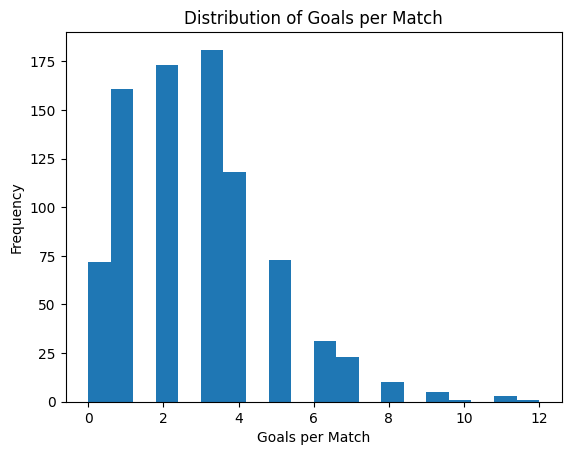

In [19]:
plt.hist(matches["TotalGoals"], bins=20)
plt.xlabel("Goals per Match")
plt.ylabel("Frequency")
plt.title("Distribution of Goals per Match")
plt.show()

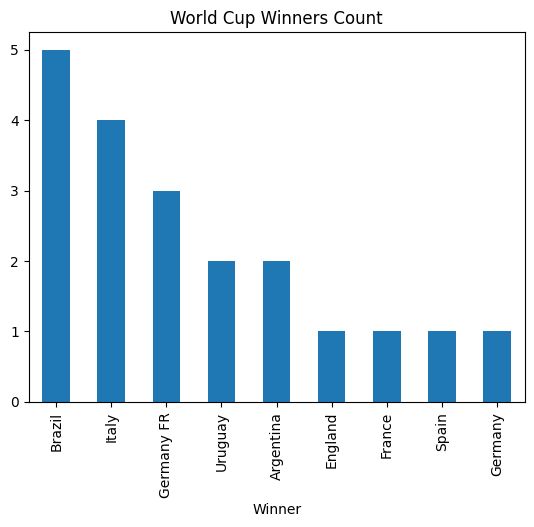

In [20]:
worldcups["Winner"].value_counts().plot(kind="bar")
plt.title("World Cup Winners Count")
plt.show()

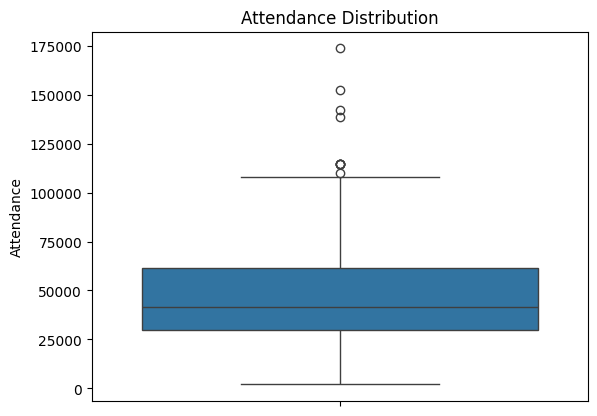

In [21]:
sns.boxplot(y=matches["Attendance"])
plt.title("Attendance Distribution")
plt.show()

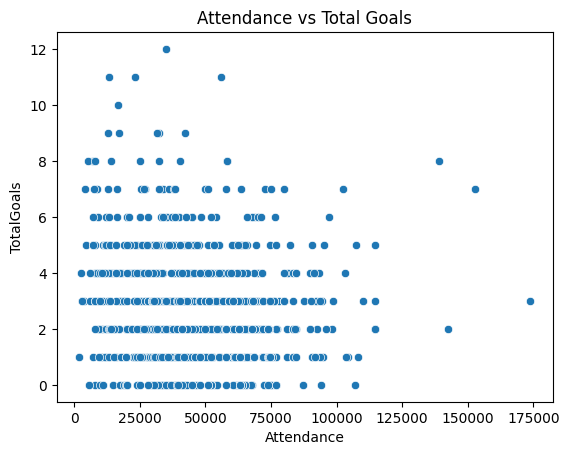

In [22]:
sns.scatterplot(x=matches["Attendance"], y=matches["TotalGoals"])
plt.title("Attendance vs Total Goals")
plt.show()

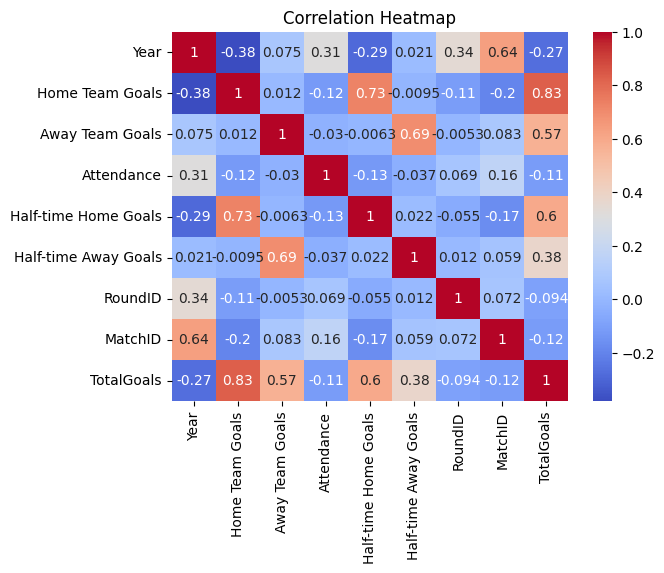

In [23]:
numeric_cols = matches.select_dtypes(include="number")
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

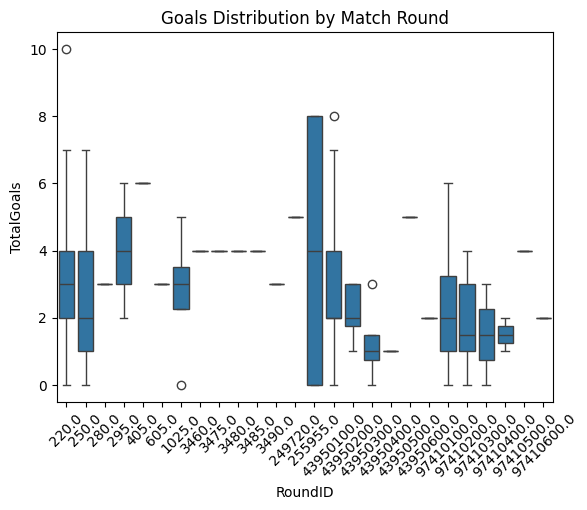

In [24]:
filtered_matches = matches[matches["RoundID"] % 5 == 0]

sns.boxplot(x=filtered_matches["RoundID"], y=filtered_matches["TotalGoals"])
plt.xticks(rotation=45)
plt.title("Goals Distribution by Match Round")
plt.show()


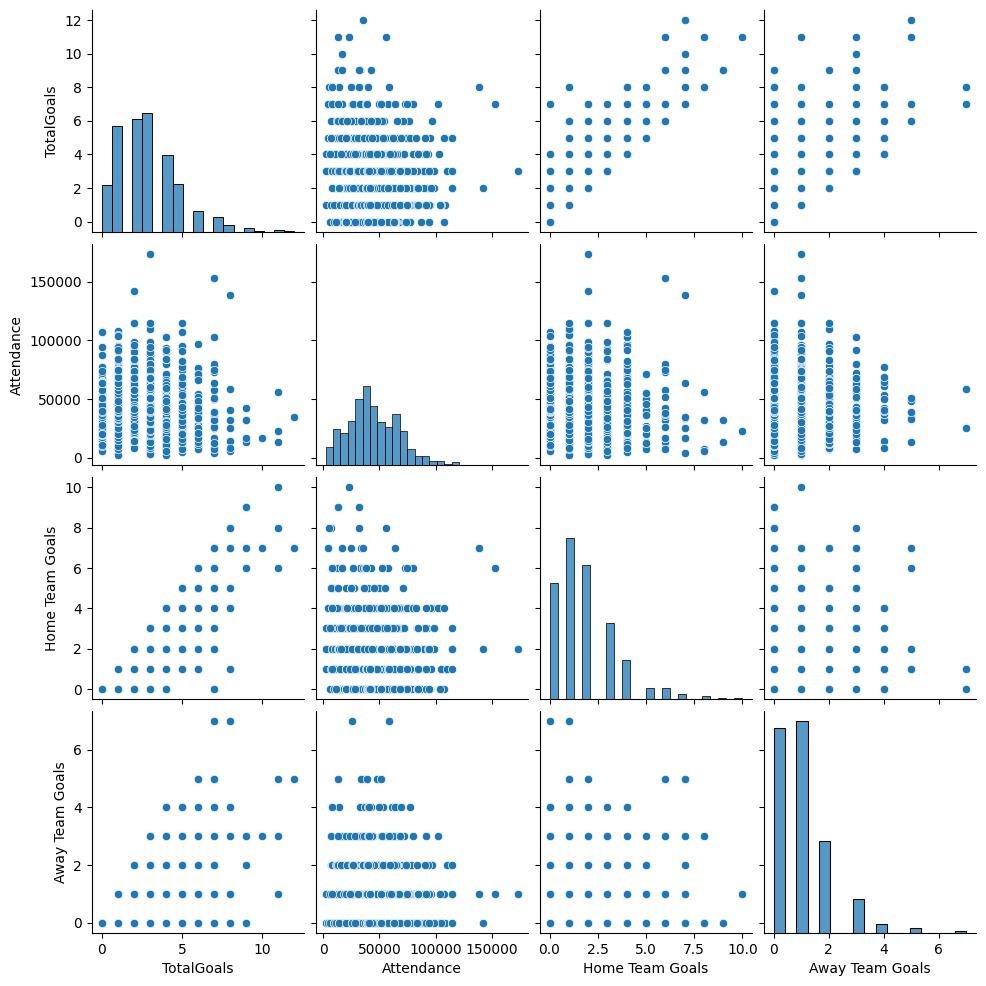

In [25]:
sns.pairplot(
    matches[['TotalGoals', 'Attendance', 'Home Team Goals', 'Away Team Goals']]
)
plt.show()

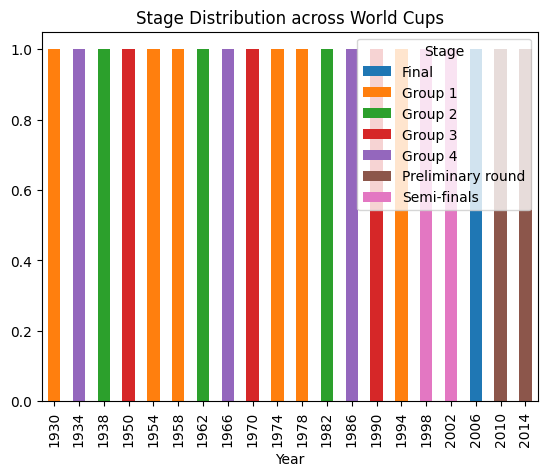

In [26]:
pd.crosstab(worldcups['Year'], matches['Stage']).plot(kind='bar', stacked=True)
plt.title("Stage Distribution across World Cups")
plt.show()

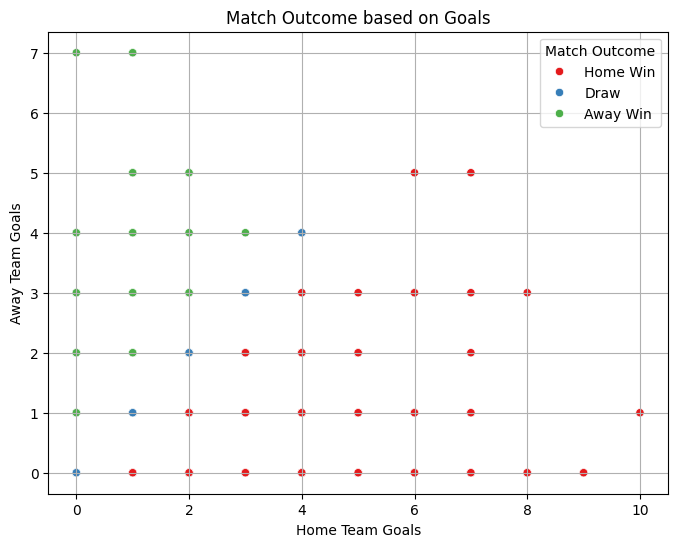

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

matches["Winner"] = matches.apply(
    lambda x: "Home Win" if x["Home Team Goals"] > x["Away Team Goals"]
    else "Away Win" if x["Home Team Goals"] < x["Away Team Goals"]
    else "Draw",
    axis=1
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=matches,
    x="Home Team Goals",
    y="Away Team Goals",
    hue="Winner",
    palette="Set1"
)

plt.title("Match Outcome based on Goals")
plt.xlabel("Home Team Goals")
plt.ylabel("Away Team Goals")
plt.legend(title="Match Outcome")
plt.grid(True)
plt.show()


# KNN Implementation

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [29]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:
# Create target variable
matches["Winner"] = matches.apply(
    lambda x: "Home Win" if x["Home Team Goals"] > x["Away Team Goals"]
    else "Away Win" if x["Home Team Goals"] < x["Away Team Goals"]
    else "Draw",
    axis=1
)


# Split the data into features(X) and target(Y)
X = matches[["Year", "Attendance"]]
y = matches["Winner"]

# target variable encoding
le = LabelEncoder()
y = le.fit_transform(y)

# Handle missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scaling data using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
# Fitting and evaluating data
knn = KNeighborsClassifier(n_neighbors=4, metric='manhattan')
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [48]:
from sklearn.model_selection import KFold, cross_val_score

In [49]:
knn = KNeighborsClassifier(n_neighbors=5)

In [50]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [51]:
scores = cross_val_score(knn, X, y, cv=kfold, scoring='accuracy')

print("Accuracy for each fold:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Accuracy for each fold: [0.89508197 0.90491803 0.90153173 0.89496718 0.89824945]
Mean Accuracy: 0.898949671772429
Standard Deviation: 0.003836614617758826


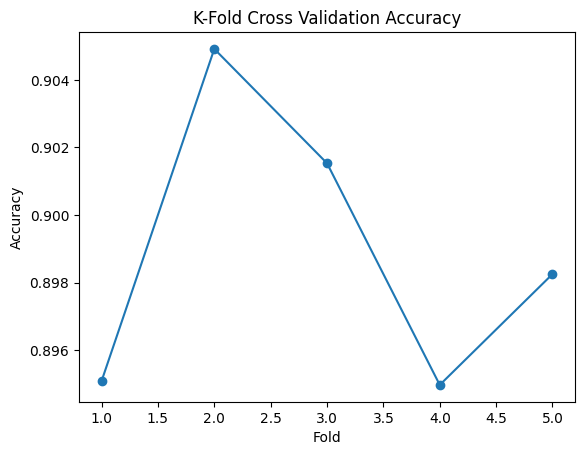

In [52]:
plt.plot(range(1,6), scores, marker='o')

plt.title("K-Fold Cross Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.show()

In [33]:
# Making predictions 
y_pred = knn.predict(X_test)

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9038251366120219


In [35]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 13   8  18]
 [  6 736  20]
 [ 21  15  78]]


In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.33      0.33        39
           1       0.97      0.97      0.97       762
           2       0.67      0.68      0.68       114

    accuracy                           0.90       915
   macro avg       0.66      0.66      0.66       915
weighted avg       0.91      0.90      0.90       915



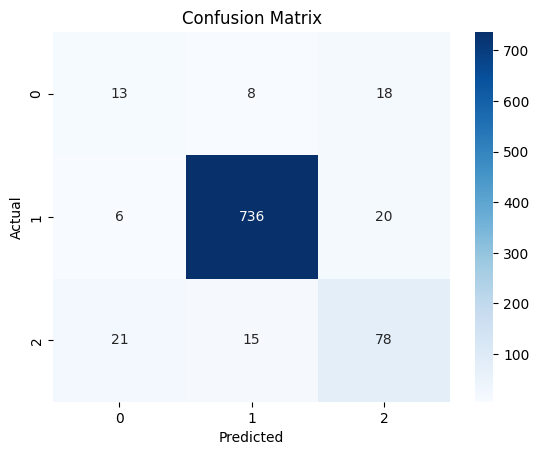

In [37]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [38]:
k_values = range(1, 15)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

In [39]:
knn_results = pd.DataFrame({
    "K Value": k_values,
    "Accuracy": accuracies
})

knn_results

,K Value,Accuracy
0,1,0.893989
1,2,0.881967
2,3,0.898361
3,4,0.903825
4,5,0.898361
5,6,0.898361
6,7,0.906011
7,8,0.896175
8,9,0.903825
9,10,0.908197


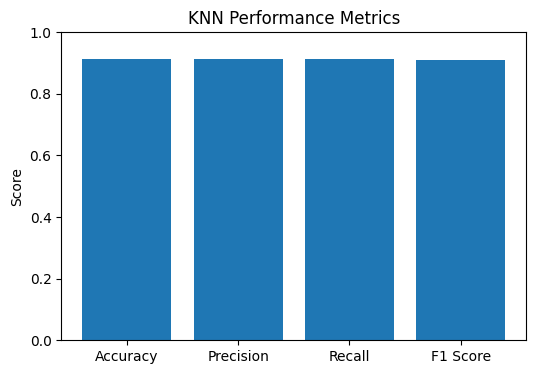

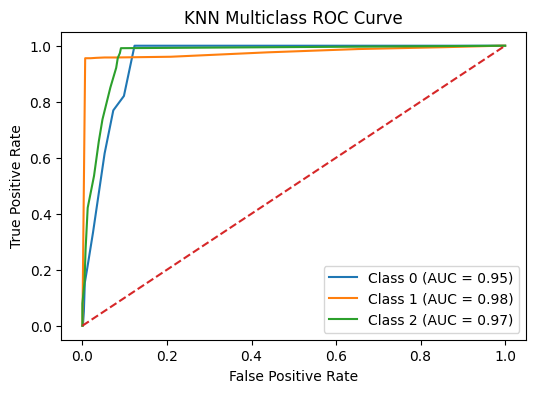

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = [accuracy, precision, recall, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Bar graph
plt.figure(figsize=(6,4))
plt.bar(labels, metrics)
plt.title("KNN Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

# ROC Curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Get unique classes
classes = np.unique(y_test)

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=classes)

# Probability predictions
y_score = knn.predict_proba(X_test)

plt.figure(figsize=(6,4))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN Multiclass ROC Curve")
plt.legend()
plt.show()